# Calculate offset between tray and magnetometer

In [23]:
import os
import glob
import pandas as pd
import pmagpy.pmag as pmag
import pmagpy.ipmag as ipmag
import matplotlib.pyplot as plt
import numpy as np

def load_rmg_df(file_path):
    """
    Load a .rmg file using the second line as header.

    Parameters
    ----------
    file_path : str
        Path to the .rmg file.

    Returns
    -------
    pd.DataFrame
        Parsed DataFrame with header from line 2 and source_file column.
    """
    with open(file_path, "r") as f:
        lines = f.readlines()
    headers = [h.strip() for h in lines[1].strip().split(",")]
    data = [line.strip().split(",") for line in lines[2:]]
    df = pd.DataFrame(data, columns=headers)
    df["source_file"] = os.path.basename(file_path)
    return df

def collect_core_dec_inc_from_rmg_folder(folder_path):
    """
    Collect Core Dec and Core Inc values from all .rmg files in folder.

    Parameters
    ----------
    folder_path : str
        Path to folder containing .rmg files.

    Returns
    -------
    pd.DataFrame
        DataFrame with source_file, Core Dec, Core Inc.
    """
    all_data = []
    for file_path in glob.glob(os.path.join(folder_path, "*.rmg")):
        df = load_rmg_df(file_path)
        if df.empty or "Core Dec" not in df.columns:
            continue
        nrm_rows = df[df[df.columns[0]].str.strip() == "NRM"]
        nrm_rows = nrm_rows[["Core Dec", "Core Inc", "source_file"]].copy()
        nrm_rows["Core Dec"] = pd.to_numeric(nrm_rows["Core Dec"], errors="coerce")
        nrm_rows["Core Inc"] = pd.to_numeric(nrm_rows["Core Inc"], errors="coerce")
        all_data.append(nrm_rows.dropna(subset=["Core Dec", "Core Inc"]))

    if all_data:
        return pd.concat(all_data, ignore_index=True)
    else:
        return pd.DataFrame(columns=["Core Dec", "Core Inc", "source_file"])

In [25]:
# Example usage:
folder = "SRxyMN"
core_df = collect_core_dec_inc_from_rmg_folder(folder)
core_df = core_df[core_df["source_file"] != "SRxy38.rmg"]
core_df.head()

,Core Dec,Core Inc,source_file
0,169.967065,-1.505916,SRxy19.rmg
1,176.336345,0.301510,SRxy25.rmg
2,181.012311,0.265803,SRxy31.rmg
3,179.180638,-1.028340,SRxy30.rmg
4,180.117341,0.227644,SRxy24.rmg


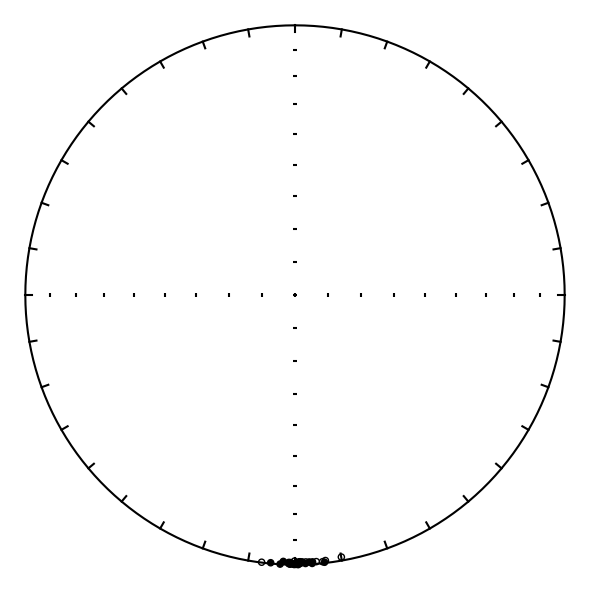

In [8]:
fignum = 1 
plt.figure(num=fignum,figsize=(6,6)) 
ipmag.plot_net(fignum)
ipmag.plot_di(dec=core_df['Core Dec'].tolist(), 
              inc=core_df['Core Inc'].tolist())

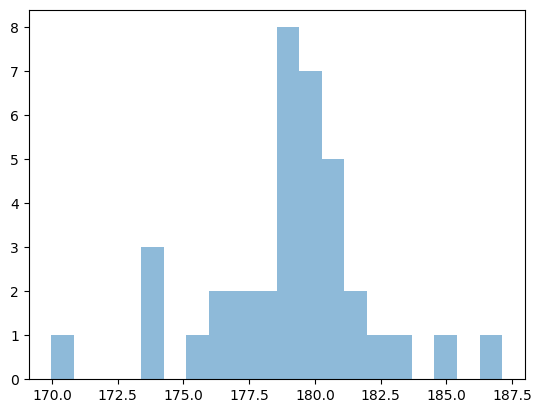

In [26]:
plt.hist(core_df['Core Dec'], bins=20, alpha=0.5, label='Core Dec')
plt.show()

In [10]:
ipmag.fisher_mean(dec=core_df['Core Dec'].tolist(), 
                  inc=core_df['Core Inc'].tolist())

{'dec': 179.11913441228094,
 'inc': -0.2225421932781348,
 'n': 37,
 'r': 36.94054544822829,
 'k': 605.5045228199153,
 'alpha95': 0.9575940007921925,
 'csd': 3.2917460504105995}

In [27]:
core_df['Core Dec'].mean()

179.11841367251876

In [28]:
def fisher_mean_with_outlier_rejection(core_df, angle_threshold_deg=30):
    """
    Compute Fisher mean of Core Dec/Inc, reject outliers > angle_threshold_deg from mean.

    Parameters
    ----------
    core_df : pd.DataFrame
        DataFrame with columns 'Core Dec', 'Core Inc'
    angle_threshold_deg : float
        Threshold angular distance in degrees to define outliers

    Returns
    -------
    dict
        Dictionary with filtered data, outliers, and final Fisher mean
    """
    decs = core_df["Core Dec"].to_numpy()
    incs = core_df["Core Inc"].to_numpy()
    mean_result = ipmag.fisher_mean(dec=decs.tolist(), inc=incs.tolist())
    mean_dir = [mean_result["dec"], mean_result["inc"]]

    angles = [
        pmag.angle([d, i], mean_dir)
        for d, i in zip(decs, incs)
    ]
    angles = np.array(angles)

    is_outlier = angles > angle_threshold_deg
    filtered_df = core_df.loc[~is_outlier].copy()
    outliers_df = core_df.loc[is_outlier].copy()

    if not filtered_df.empty:
        filtered_decs = filtered_df["Core Dec"].to_numpy()
        filtered_incs = filtered_df["Core Inc"].to_numpy()
        new_mean = ipmag.fisher_mean(dec=filtered_decs.tolist(), inc=filtered_incs.tolist())
    else:
        new_mean = None

    return {
        "filtered_df": filtered_df,
        "outliers_df": outliers_df,
        "mean": new_mean,
        "angle_to_mean": angles
    }

# Example usage
result = fisher_mean_with_outlier_rejection(core_df, angle_threshold_deg=8)
mean = result["mean"]
print(f"Filtered Fisher Mean: Dec = {mean['dec']:.2f}, Inc = {mean['inc']:.2f}, k = {mean['k']:.1f}")

Filtered Fisher Mean: Dec = 179.15, Inc = -0.19, k = 925.6


In [29]:
result["mean"]

{'dec': 179.1516148867666,
 'inc': -0.18731863319461545,
 'n': 35,
 'r': 34.96326773932443,
 'k': 925.616865792641,
 'alpha95': 0.7970904897165393,
 'csd': 2.6623759970704803}

In [30]:
filtered_df=result["filtered_df"]

(array([3., 3., 3., 9., 8., 6., 2., 1.]),
 array([173.46805742427   , 174.93384040017088, 176.39962337607176,
        177.86540635197264, 179.33118932787352, 180.79697230377437,
        182.26275527967525, 183.72853825557613, 185.194321231477  ]),
 <BarContainer object of 8 artists>)

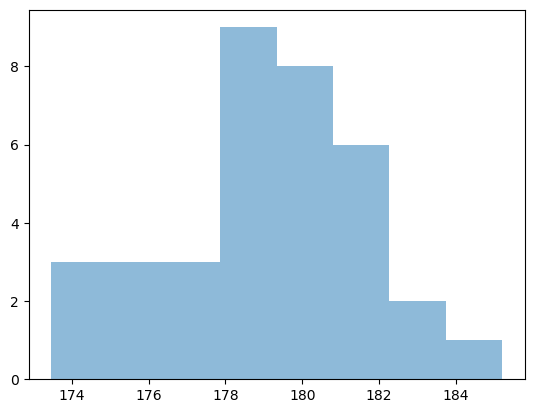

In [31]:
plt.hist(filtered_df['Core Dec'], bins=8, alpha=0.5, label='Core Dec')